In [1]:
import pandas as pd

df = pd.DataFrame({
    'name':['john','mary','peter','jeff','bill','lisa','jose'],
    'age':[23,78,22,19,45,33,20],
    'gender':['M','F','M','M','M','F','M'],
    'state':['california','dc','california','dc','california','texas','texas'],
    'num_children':[2,0,0,3,2,1,4],
    'num_pets':[5,1,0,5,2,2,3]
})

df

,name,age,gender,state,num_children,num_pets
0,john,23,M,california,2,5
1,mary,78,F,dc,0,1
2,peter,22,M,california,0,0
3,jeff,19,M,dc,3,5
4,bill,45,M,california,2,2
5,lisa,33,F,texas,1,2
6,jose,20,M,texas,4,3


### 1. 위 데이터를 이용하여 다음 plot을 작성하시오.

<img src='시각화1.png' />


In [14]:
data = df.groupby(['gender', 'state']).size().unstack().transform(lambda x: 100 * x / x.sum())
data

state,california,dc,texas
gender,,,
F,NaN,50.0,50.0
M,100.0,50.0,50.0


In [3]:
data = df.groupby(['gender','state']).size().groupby(level=0).apply(
    lambda x: 100 * x / x.sum()
).unstack()
data

state,california,dc,texas
gender,,,
F,NaN,50.0,50.0
M,60.0,20.0,20.0


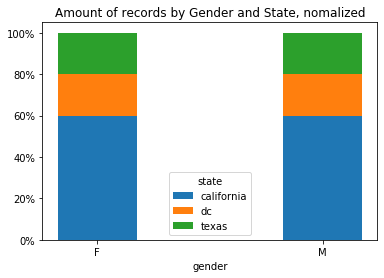

In [19]:
data.dropna(inplace=True)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
%matplotlib inline

x = np.arange(2)
width = 0.35
p1 = plt.bar(x, data['california'], width)
p2 = plt.bar(x, data['dc'], width, bottom=data['california'])
p3 = plt.bar(x, data['texas'], width, bottom=data['california'] + data['dc'])
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xlabel('gender')
plt.title('Amount of records by Gender and State, nomalized')
plt.xticks(x, ('F', 'M'))

plt.legend((p1[0], p2[0], p3[0]), ('california', 'dc', 'texas'), title='state')

In [15]:
url = 'https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv'

housing = pd.read_csv(url)
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 2. 위 데이터를 이용하여 다음 plot을 작성하시오.

<img src='시각화2.png' />

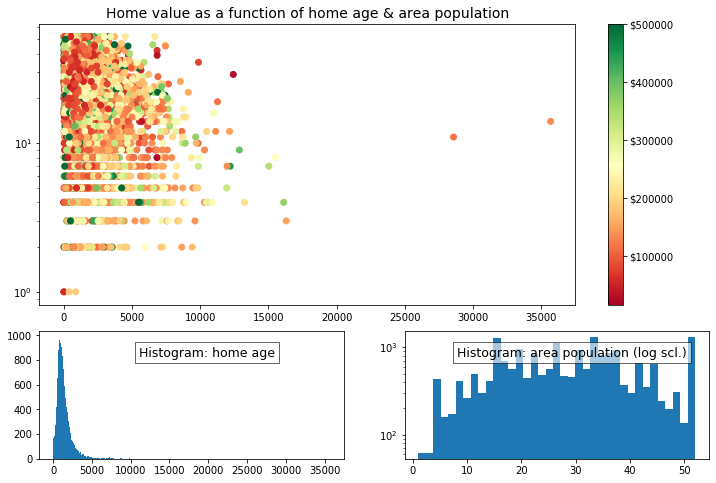

In [20]:
pop = housing['housing_median_age']
age = housing['population']
y = housing['median_house_value']

def add_titlebox(ax, text):
    ax.text(.55, .8, text,
        horizontalalignment='center',
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.6),
        fontsize=12.5)
    return ax

gridsize = (3, 2)
fig = plt.figure(figsize=(12, 8))
ax1 = plt.subplot2grid(gridsize, (0, 0), colspan=2, rowspan=2)
ax2 = plt.subplot2grid(gridsize, (2, 0))
ax3 = plt.subplot2grid(gridsize, (2, 1))

ax1.set_title('Home value as a function of home age & area population', fontsize=14)
sctr = ax1.scatter(x=age, y=pop, c=y, cmap='RdYlGn')
plt.colorbar(sctr, ax=ax1, format='$%d')
ax1.set_yscale('log')
ax2.hist(age, bins='auto')
ax3.hist(pop, bins='auto', log=True)

add_titlebox(ax2, 'Histogram: home age')
add_titlebox(ax3, 'Histogram: area population (log scl.)')